# KEXP Comment Links Exploration

This notebook explores links contained in KEXP DJ comments to understand:
1. What types of links are shared (YouTube, Bandcamp, artist websites, etc.)
2. How frequently links appear in comments
3. Patterns in link sharing
4. Most common domains and link types
5. Temporal trends in link sharing


In [1]:
import sys
from pathlib import Path
import re
from urllib.parse import urlparse
from collections import Counter
from datetime import datetime

# Add the src directory to the path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

from crate_analysis import Database

# Configure pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

# Set up plotting style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)


/Users/pooks/Dev/crate/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Connect to Database


In [2]:
# Connect to the database
db = Database()
print(f"Connected to database at: {db.db_path}")


Connected to database at: /Users/pooks/Dev/crate/data/music_kb.sqlite


## URL Extraction Functions


In [3]:
# Regex pattern to match URLs
# Matches http://, https://, www., and common URL patterns
URL_PATTERN = re.compile(
    r'(?:https?://|www\.)[^\s<>"{}|\\^`\[\]]+[^\s<>"{}|\\^`\[\].,;:!?]',
    re.IGNORECASE
)

def extract_urls(text: str) -> list[str]:
    """Extract all URLs from a text string."""
    if not text or pd.isna(text):
        return []
    return URL_PATTERN.findall(text)

def normalize_url(url: str) -> str:
    """Normalize URL by removing www. and trailing slashes."""
    url = url.strip()
    # Remove www. prefix
    if url.startswith('www.'):
        url = 'https://' + url
    # Ensure protocol
    if not url.startswith(('http://', 'https://')):
        url = 'https://' + url
    return url

def get_domain(url: str) -> str:
    """Extract domain from URL."""
    try:
        parsed = urlparse(normalize_url(url))
        domain = parsed.netloc.lower()
        # Remove www. prefix
        if domain.startswith('www.'):
            domain = domain[4:]
        return domain
    except:
        return url

def categorize_link(url: str) -> str:
    """Categorize link by domain type."""
    domain = get_domain(url).lower()
    
    # Video platforms
    if any(x in domain for x in ['youtube.com', 'youtu.be', 'vimeo.com']):
        return 'Video'
    
    # Music platforms
    if any(x in domain for x in ['bandcamp.com', 'soundcloud.com', 'spotify.com', 'apple.com/music']):
        return 'Music Platform'
    
    # Social media
    if any(x in domain for x in ['twitter.com', 'x.com', 'facebook.com', 'instagram.com']):
        return 'Social Media'
    
    # News/media
    if any(x in domain for x in ['kexp.org', 'npr.org', 'pitchfork.com', 'rollingstone.com']):
        return 'News/Media'
    
    # Artist/label websites (common patterns)
    if any(x in domain for x in ['.com', '.org', '.net']):
        return 'Website'
    
    return 'Other'


## Load Comments with Links


In [4]:
# Query all comments that are not null/empty
print("Loading comments from database...")
comments_df = db.query("""
    SELECT 
        id,
        airdate,
        artist,
        song,
        comment,
        show
    FROM fact_plays
    WHERE comment IS NOT NULL 
      AND comment != ''
      AND LENGTH(comment) > 0
""")

print(f"Total comments: {len(comments_df):,}")
print(f"Comments with potential links: {comments_df['comment'].str.contains(URL_PATTERN, regex=True, na=False).sum():,}")


Loading comments from database...
Total comments: 1,075,082
Comments with potential links: 674,490


## Extract URLs from Comments


In [5]:
# Extract URLs from each comment
print("Extracting URLs from comments...")
comments_df['urls'] = comments_df['comment'].apply(extract_urls)
comments_df['url_count'] = comments_df['urls'].apply(len)
comments_df['has_links'] = comments_df['url_count'] > 0

# Filter to only comments with links
comments_with_links = comments_df[comments_df['has_links']].copy()

print(f"\nComments with links: {len(comments_with_links):,} ({len(comments_with_links)/len(comments_df)*100:.2f}%)")
print(f"Total URLs found: {comments_with_links['url_count'].sum():,}")
print(f"Average URLs per comment (with links): {comments_with_links['url_count'].mean():.2f}")


Extracting URLs from comments...

Comments with links: 674,490 (62.74%)
Total URLs found: 810,083
Average URLs per comment (with links): 1.20


## Create URL Dataset


In [6]:
# Expand URLs into separate rows
url_rows = []
for idx, row in comments_with_links.iterrows():
    for url in row['urls']:
        url_rows.append({
            'play_id': row['id'],
            'airdate': row['airdate'],
            'artist': row['artist'],
            'song': row['song'],
            'show': row['show'],
            'comment': row['comment'],
            'url': url,
            'domain': get_domain(url),
            'category': categorize_link(url)
        })

urls_df = pd.DataFrame(url_rows)
print(f"Total URL instances: {len(urls_df):,}")
print(f"Unique URLs: {urls_df['url'].nunique():,}")
print(f"Unique domains: {urls_df['domain'].nunique():,}")

urls_df.head(10)


Total URL instances: 810,083
Unique URLs: 290,897
Unique domains: 49,719


,play_id,airdate,artist,song,show,comment,url,domain,category
0,3518526,2025-06-25T01:46:50-07:00,Marvin Gaye & Tammi Terrell,Ain’t No Mountain High Enough,63830,The extraordinary Tammi Terrell died just before her 25th birthday of brain cancer. Although Ma...,https://www.smoothradio.com/news/music/tammi-terrell-songs-death-children-age/,smoothradio.com,Website
1,3518525,2025-06-25T01:42:30-07:00,Mavis Staples & Bonnie Raitt,Turn Me Around,63830,From Mavis Staples: I’ll Take You There — An All-Star Concert Celebration. Chicago’s Auditorium ...,https://www.youtube.com/watch?v=A3r63pFUk-A,youtube.com,Video
2,3518524,2025-06-25T01:39:11-07:00,Durand Jones & The Indications,Lovers’ Holiday,63830,October 28th at Showbox SoDo\nhttps://www.youtube.com/watch?v=Isb-OF1Iffg,https://www.youtube.com/watch?v=Isb-OF1Iffg,youtube.com,Video
3,3518522,2025-06-25T01:33:03-07:00,HAIM,Down to be wrong,63830,"HAIM will be on tour in support of their fourth album ""I quit"":\n\n-Amphitheater at McMenamin's ...",https://nypost.com/2025/04/29/ticket-sales/haim-i-quit-tour-2025-where-to-buy-tickets-schedule-d...,nypost.com,Website
4,3518521,2025-06-25T01:29:19-07:00,Suzi Quatro,Devil Gate Drive,63830,"This song describes a trip to Devil Gate Drive, a fictional place where all the kids get their k...",https://bit.ly/3Zymqee,bit.ly,Other
5,3518521,2025-06-25T01:29:19-07:00,Suzi Quatro,Devil Gate Drive,63830,"This song describes a trip to Devil Gate Drive, a fictional place where all the kids get their k...",http://www.suziquatro.com/,suziquatro.com,Website
6,3518520,2025-06-25T01:26:25-07:00,Dream Wife,Social Lubrication,63830,One of top ten albums of 2023 : https://kexp.org/read/2023/12/4/kexp-djs-top-albums-of-2023/\n\n...,https://kexp.org/read/2023/12/4/kexp-djs-top-albums-of-2023/,kexp.org,News/Media
7,3518520,2025-06-25T01:26:25-07:00,Dream Wife,Social Lubrication,63830,One of top ten albums of 2023 : https://kexp.org/read/2023/12/4/kexp-djs-top-albums-of-2023/\n\n...,https://www.youtube.com/watch?app=desktop&v=NR33js0fjCQ,youtube.com,Video
8,3518517,2025-06-25T01:15:26-07:00,Penny Penny,Shilungu,63830,"Penny Penny's 2001 impossibly rare Kwaito House monster ""Shilungu”.\n\nA hypnotic, percussive, g...",https://www.youtube.com/watch?v=AymFvZ9EZc4,youtube.com,Video
9,3518516,2025-06-25T01:13:29-07:00,Obongjayar,Jellyfish,63830,"With a truly unique sound blending everything from electronic, soul, pop, afro-beat and more, hi...",https://obongjayar.bandcamp.com/album/paradise-now,obongjayar.bandcamp.com,Music Platform


## Test Link Validity

This section tests the HTTP validity of all extracted links by making HEAD requests to check status codes.


In [7]:
import httpx
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from collections import Counter
from tqdm import tqdm

# Configuration
MAX_WORKERS = 50  # Concurrent requests
TIMEOUT = 10  # Seconds
MAX_URLS_TO_TEST = 1000  # Limit for initial testing (set to None to test all)

print("Link Validity Testing Configuration:")
print(f"  Max concurrent requests: {MAX_WORKERS}")
print(f"  Timeout per request: {TIMEOUT}s")
print(f"  Max URLs to test: {MAX_URLS_TO_TEST if MAX_URLS_TO_TEST else 'All URLs'}")
print()

# Get unique URLs to test
unique_urls = urls_df['url'].unique()
if MAX_URLS_TO_TEST:
    # Sample URLs for testing (prioritize by frequency)
    url_counts = urls_df['url'].value_counts()
    # Take top N most common URLs
    top_urls = url_counts.head(MAX_URLS_TO_TEST).index.tolist()
    urls_to_test = top_urls
    print(f"Testing top {len(urls_to_test)} most common URLs (out of {len(unique_urls):,} unique URLs)")
else:
    urls_to_test = unique_urls.tolist()
    print(f"Testing all {len(urls_to_test):,} unique URLs")

print()


ModuleNotFoundError: No module named 'httpx'

In [ ]:
def test_url(url: str) -> dict:
    """Test a single URL and return status information."""
    result = {
        'url': url,
        'status_code': None,
        'error': None,
        'redirect_url': None,
        'content_type': None,
        'response_time': None
    }
    
    try:
        # Normalize URL
        normalized = normalize_url(url)
        
        start_time = time.time()
        
        # Use HEAD request first (faster), fall back to GET if needed
        with httpx.Client(timeout=TIMEOUT, follow_redirects=True, verify=True) as client:
            try:
                response = client.head(normalized, allow_redirects=True)
            except:
                # Some servers don't support HEAD, try GET
                response = client.get(normalized, allow_redirects=True)
            
            result['status_code'] = response.status_code
            result['content_type'] = response.headers.get('content-type', '')
            result['redirect_url'] = str(response.url) if response.url != normalized else None
            result['response_time'] = time.time() - start_time
            
    except httpx.TimeoutException:
        result['error'] = 'Timeout'
    except httpx.ConnectError:
        result['error'] = 'Connection Error'
    except httpx.HTTPStatusError as e:
        result['status_code'] = e.response.status_code
        result['error'] = 'HTTP Error'
    except Exception as e:
        result['error'] = str(type(e).__name__)
    
    return result

# Test URLs with progress bar
print("Testing URLs...")
results = []
start_time = time.time()

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Submit all tasks
    future_to_url = {executor.submit(test_url, url): url for url in urls_to_test}
    
    # Process results as they complete
    with tqdm(total=len(urls_to_test), desc="Testing URLs") as pbar:
        for future in as_completed(future_to_url):
            result = future.result()
            results.append(result)
            pbar.update(1)

elapsed_time = time.time() - start_time
print(f"\nCompleted testing {len(results)} URLs in {elapsed_time:.2f} seconds")
print(f"Average time per URL: {elapsed_time/len(results):.3f}s")


In [ ]:
# Create results DataFrame
link_test_results = pd.DataFrame(results)

# Categorize status codes
def categorize_status(status_code: int | None, error: str | None) -> str:
    """Categorize HTTP status code."""
    if error:
        return 'Error'
    if status_code is None:
        return 'Unknown'
    if 200 <= status_code < 300:
        return 'Success (2xx)'
    elif 300 <= status_code < 400:
        return 'Redirect (3xx)'
    elif 400 <= status_code < 500:
        return 'Client Error (4xx)'
    elif 500 <= status_code < 600:
        return 'Server Error (5xx)'
    else:
        return 'Other'

link_test_results['status_category'] = link_test_results.apply(
    lambda row: categorize_status(row['status_code'], row['error']), axis=1
)

# Statistics
print("="*80)
print("LINK VALIDITY TEST RESULTS")
print("="*80)
print(f"\nTotal URLs tested: {len(link_test_results):,}")

# Status code distribution
print("\nStatus Code Distribution:")
status_counts = link_test_results['status_category'].value_counts()
for category, count in status_counts.items():
    pct = count / len(link_test_results) * 100
    print(f"  {category}: {count:,} ({pct:.2f}%)")

# HTTP status codes
print("\nHTTP Status Codes (top 20):")
status_code_counts = link_test_results['status_code'].value_counts().head(20)
for code, count in status_code_counts.items():
    pct = count / len(link_test_results) * 100
    print(f"  {code}: {count:,} ({pct:.2f}%)")

# Errors
error_counts = link_test_results['error'].value_counts()
if len(error_counts) > 0:
    print("\nError Types:")
    for error, count in error_counts.items():
        pct = count / len(link_test_results) * 100
        print(f"  {error}: {count:,} ({pct:.2f}%)")

# Response times
valid_responses = link_test_results[link_test_results['response_time'].notna()]
if len(valid_responses) > 0:
    print(f"\nResponse Time Statistics:")
    print(f"  Mean: {valid_responses['response_time'].mean():.3f}s")
    print(f"  Median: {valid_responses['response_time'].median():.3f}s")
    print(f"  Min: {valid_responses['response_time'].min():.3f}s")
    print(f"  Max: {valid_responses['response_time'].max():.3f}s")


In [ ]:
# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Status category distribution
ax1 = axes[0, 0]
status_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Status Code Categories', fontsize=14, fontweight='bold')
ax1.set_xlabel('Category', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 2. Top HTTP status codes
ax2 = axes[0, 1]
status_code_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_title('Top HTTP Status Codes', fontsize=14, fontweight='bold')
ax2.set_xlabel('Count', fontsize=12)
ax2.set_ylabel('Status Code', fontsize=12)
ax2.invert_yaxis()

# 3. Error types (if any)
ax3 = axes[1, 0]
if len(error_counts) > 0:
    error_counts.plot(kind='bar', ax=ax3, color='red')
    ax3.set_title('Error Types', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Error Type', fontsize=12)
    ax3.set_ylabel('Count', fontsize=12)
    ax3.tick_params(axis='x', rotation=45)
else:
    ax3.text(0.5, 0.5, 'No Errors', ha='center', va='center', fontsize=16)
    ax3.set_title('Error Types', fontsize=14, fontweight='bold')

# 4. Response time distribution
ax4 = axes[1, 1]
if len(valid_responses) > 0:
    valid_responses['response_time'].hist(bins=50, ax=ax4, color='green', alpha=0.7)
    ax4.set_title('Response Time Distribution', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Response Time (seconds)', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.axvline(valid_responses['response_time'].mean(), color='red', linestyle='--', 
                label=f"Mean: {valid_responses['response_time'].mean():.3f}s")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, 'No Response Times', ha='center', va='center', fontsize=16)
    ax4.set_title('Response Time Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# Show examples of broken/invalid links
print("="*80)
print("EXAMPLES OF BROKEN/INVALID LINKS")
print("="*80)

# 4xx errors
client_errors = link_test_results[
    (link_test_results['status_code'] >= 400) & 
    (link_test_results['status_code'] < 500)
].head(10)

if len(client_errors) > 0:
    print("\nClient Errors (4xx) - Top 10:")
    for idx, row in client_errors.iterrows():
        print(f"\n  Status: {row['status_code']}")
        print(f"  URL: {row['url']}")
        if row['error']:
            print(f"  Error: {row['error']}")

# 5xx errors
server_errors = link_test_results[
    (link_test_results['status_code'] >= 500) & 
    (link_test_results['status_code'] < 600)
].head(10)

if len(server_errors) > 0:
    print("\n\nServer Errors (5xx) - Top 10:")
    for idx, row in server_errors.iterrows():
        print(f"\n  Status: {row['status_code']}")
        print(f"  URL: {row['url']}")
        if row['error']:
            print(f"  Error: {row['error']}")

# Connection/timeout errors
connection_errors = link_test_results[link_test_results['error'].notna()].head(10)

if len(connection_errors) > 0:
    print("\n\nConnection/Timeout Errors - Top 10:")
    for idx, row in connection_errors.iterrows():
        print(f"\n  Error: {row['error']}")
        print(f"  URL: {row['url']}")


In [ ]:
# Analyze by domain
print("="*80)
print("LINK VALIDITY BY DOMAIN")
print("="*80)

# Merge test results with original URL data
urls_with_status = urls_df.merge(
    link_test_results[['url', 'status_code', 'status_category', 'error']],
    on='url',
    how='left'
)

# Group by domain and calculate statistics
domain_stats = urls_with_status.groupby('domain').agg({
    'status_code': ['count', lambda x: (x >= 200) & (x < 300) if x.notna().any() else pd.Series([0])],
    'url': 'nunique'
}).reset_index()

domain_stats.columns = ['domain', 'total_links', 'success_count', 'unique_urls']
domain_stats['success_rate'] = (domain_stats['success_count'] / domain_stats['total_links'] * 100).round(2)
domain_stats = domain_stats.sort_values('total_links', ascending=False)

print("\nTop 20 Domains by Link Count (with success rates):")
print(domain_stats.head(20).to_string(index=False))

# Show domains with low success rates
low_success = domain_stats[
    (domain_stats['total_links'] >= 10) & 
    (domain_stats['success_rate'] < 50)
].sort_values('success_rate')

if len(low_success) > 0:
    print(f"\n\nDomains with Low Success Rate (<50%, min 10 links):")
    print(low_success.head(20).to_string(index=False))


In [ ]:
# KEXP-specific link analysis
print("="*80)
print("KEXP.ORG LINK VALIDITY")
print("="*80)

kexp_test_results = link_test_results[
    link_test_results['url'].str.contains('kexp.org', case=False, na=False)
]

if len(kexp_test_results) > 0:
    print(f"\nKEXP links tested: {len(kexp_test_results):,}")
    
    kexp_status_counts = kexp_test_results['status_category'].value_counts()
    print("\nKEXP Link Status Distribution:")
    for category, count in kexp_status_counts.items():
        pct = count / len(kexp_test_results) * 100
        print(f"  {category}: {count:,} ({pct:.2f}%)")
    
    # Show broken KEXP links
    broken_kexp = kexp_test_results[
        (kexp_test_results['status_code'] >= 400) | 
        (kexp_test_results['error'].notna())
    ]
    
    if len(broken_kexp) > 0:
        print(f"\n\nBroken KEXP Links ({len(broken_kexp)}):")
        for idx, row in broken_kexp.head(10).iterrows():
            print(f"\n  Status: {row['status_code']} | Error: {row['error']}")
            print(f"  URL: {row['url']}")
    else:
        print("\n\n✅ All tested KEXP links are valid!")
else:
    print("\nNo KEXP links in test sample. Increase MAX_URLS_TO_TEST to include more.")


## Link Category Analysis


Links by Category:
category
Website           254342
Music Platform    163138
Video             142067
News/Media        137719
Other              80505
Social Media       32312
Name: count, dtype: int64

Percentage distribution:
category
Website           31.40
Music Platform    20.14
Video             17.54
News/Media        17.00
Other              9.94
Social Media       3.99
Name: count, dtype: float64


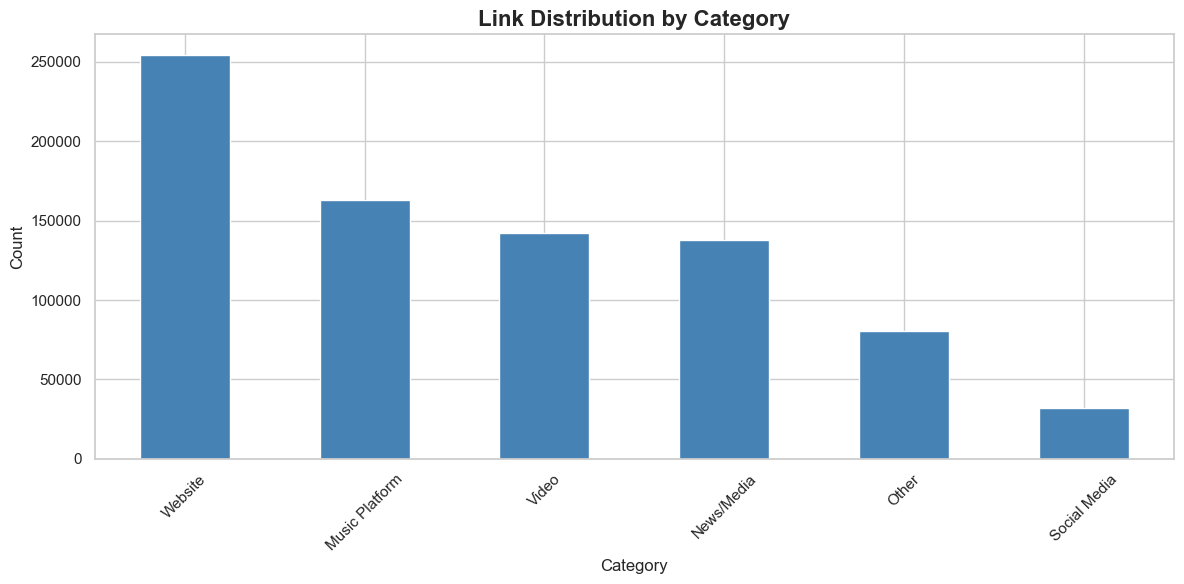

In [ ]:
# Count by category
category_counts = urls_df['category'].value_counts()
print("Links by Category:")
print(category_counts)
print(f"\nPercentage distribution:")
print((category_counts / len(urls_df) * 100).round(2))

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
category_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Link Distribution by Category', fontsize=16, fontweight='bold')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Top Domains


Top 20 Domains:
domain
youtube.com         103211
kexp.org             71862
bit.ly               55362
blog.kexp.org        50310
youtu.be             37921
facebook.com         23605
tinyurl.com          13191
soundcloud.com       12605
pitchfork.com         8457
allmusic.com          6992
instagram.com         4280
npr.org               3455
stereogum.com         3095
rollingstone.com      2973
theguardian.com       2463
genius.com            2339
twitter.com           2245
discogs.com           2142
nytimes.com           1754
nme.com               1596
Name: count, dtype: int64


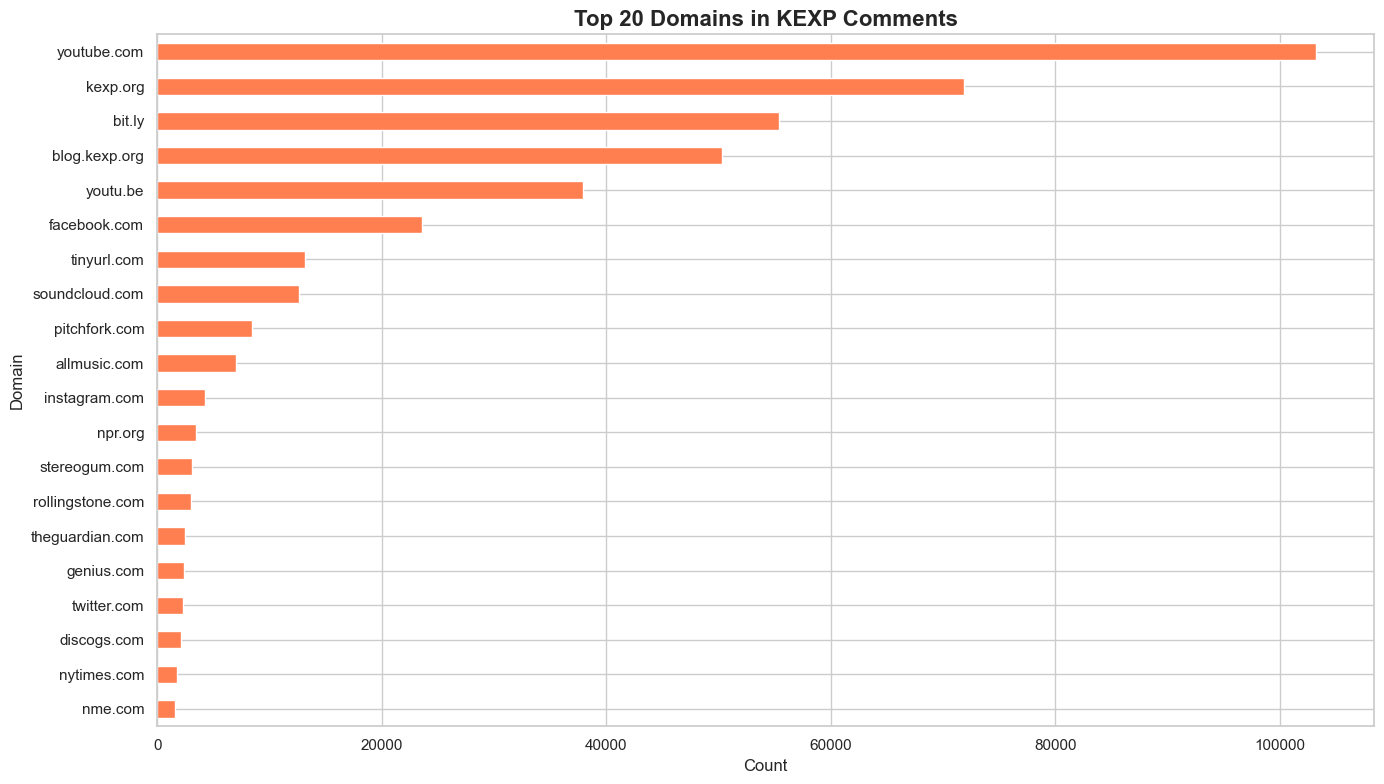

In [ ]:
# Top domains
top_domains = urls_df['domain'].value_counts().head(20)
print("Top 20 Domains:")
print(top_domains)

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
top_domains.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 Domains in KEXP Comments', fontsize=16, fontweight='bold')
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Domain', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## YouTube Links Analysis


In [ ]:
# Filter YouTube links
youtube_links = urls_df[urls_df['category'] == 'Video'].copy()
youtube_links = youtube_links[youtube_links['domain'].str.contains('youtube', case=False, na=False)]

print(f"YouTube links: {len(youtube_links):,}")
print(f"Percentage of all links: {len(youtube_links)/len(urls_df)*100:.2f}%")

# Extract video IDs if possible
def extract_video_id(url: str) -> str | None:
    """Extract YouTube video ID from URL."""
    patterns = [
        r'(?:v=|\/)([0-9A-Za-z_-]{11}).*',
        r'(?:embed\/)([0-9A-Za-z_-]{11})',
        r'(?:youtu\.be\/)([0-9A-Za-z_-]{11})'
    ]
    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return None

youtube_links['video_id'] = youtube_links['url'].apply(extract_video_id)
youtube_links_with_id = youtube_links[youtube_links['video_id'].notna()]

print(f"YouTube links with extractable video ID: {len(youtube_links_with_id):,}")

# Show sample
print("\nSample YouTube links:")
display(youtube_links[['artist', 'song', 'url', 'airdate']].head(10))


YouTube links: 103,247
Percentage of all links: 12.75%
YouTube links with extractable video ID: 101,043

Sample YouTube links:


,artist,song,url,airdate
1,Mavis Staples & Bonnie Raitt,Turn Me Around,https://www.youtube.com/watch?v=A3r63pFUk-A,2025-06-25T01:42:30-07:00
2,Durand Jones & The Indications,Lovers’ Holiday,https://www.youtube.com/watch?v=Isb-OF1Iffg,2025-06-25T01:39:11-07:00
7,Dream Wife,Social Lubrication,https://www.youtube.com/watch?app=desktop&v=NR33js0fjCQ,2025-06-25T01:26:25-07:00
8,Penny Penny,Shilungu,https://www.youtube.com/watch?v=AymFvZ9EZc4,2025-06-25T01:15:26-07:00
11,Alexander O’Neal,Fake (edit),https://www.youtube.com/watch?v=vN1RYACiXNs,2025-06-25T01:04:49-07:00
18,Ana Tijoux con Shadia Mansour,Somos sur,https://www.youtube.com/watch?v=teFgKyisViw,2025-06-25T00:42:22-07:00
25,The Drums,Days,https://www.youtube.com/watch?v=A3KxGhL2pzs,2025-06-25T00:26:24-07:00
46,Girl Ray,Wanna Dance,https://www.youtube.com/watch?v=cxklExhgjc4,2025-06-24T23:11:59-07:00
90,Enya,Orinoco Flow,https://www.youtube.com/watch?v=LTrk4X9ACtw,2025-06-24T18:49:11-07:00
95,Kevin Morby,A Random Act of Kindness,https://www.youtube.com/watch?v=0cYriEUT1Qk&t=3s,2025-06-24T18:33:23-07:00


## Bandcamp Links Analysis


In [ ]:
# Filter Bandcamp links
bandcamp_links = urls_df[urls_df['domain'].str.contains('bandcamp', case=False, na=False)]

print(f"Bandcamp links: {len(bandcamp_links):,}")
print(f"Percentage of all links: {len(bandcamp_links)/len(urls_df)*100:.2f}%")

# Show sample
print("\nSample Bandcamp links:")
display(bandcamp_links[['artist', 'song', 'url', 'airdate']].head(10))


Bandcamp links: 149,398
Percentage of all links: 18.44%

Sample Bandcamp links:


,artist,song,url,airdate
9,Obongjayar,Jellyfish,https://obongjayar.bandcamp.com/album/paradise-now,2025-06-25T01:13:29-07:00
24,Perfume Genius,Queen,https://perfumegenius.bandcamp.com/album/too-bright,2025-06-25T00:32:14-07:00
31,DEBBY FRIDAY,All I Wanna Do Is Party,https://debbyfriday.bandcamp.com/track/all-i-wanna-do-is-party-1,2025-06-25T00:07:28-07:00
55,Dam Swindle,Only Ever Now,https://damswindle.bandcamp.com/album/open,2025-06-24T22:42:30-07:00
69,"Daphni, Sofia Kourtesis",Unidos (Original Mix),https://sofiakourtesis.bandcamp.com/album/volver,2025-06-24T21:39:16-07:00
71,Siraba,Kôngô,https://siraba.bandcamp.com/album/d-mba-k-le-k-ng,2025-06-24T21:05:36-07:00
72,Azuka Moweta and His Anioma Brothers Band of Africa,Kamsi Ebinu Ndum (Captain Planet remix),https://palenquerecords.bandcamp.com/album/ekobe-global-azuka-moweta-and-his-anioma-brothers-ban...,2025-06-24T20:56:05-07:00
73,Seun Kuti & Egypt 80 feat. Kamasi Washington,Move (Keep Moving version),https://seunkutiegypt80.bandcamp.com/album/move-keep-moving-version,2025-06-24T20:50:16-07:00
74,Majid Bekkas,Soudani Manayou (Cervo Edit),https://majidbekkas.bandcamp.com/album/al-qantara,2025-06-24T20:41:58-07:00
76,Etran de L’Aïr,Amidinine,https://etrandelair.bandcamp.com/track/amidinine,2025-06-24T20:17:24-07:00


## KEXP Blog Links Analysis


In [ ]:
# Filter KEXP blog links (kexp.org and blog.kexp.org)
kexp_links = urls_df[urls_df['domain'].str.contains('kexp.org', case=False, na=False)].copy()

print(f"KEXP blog links: {len(kexp_links):,}")
print(f"Percentage of all links: {len(kexp_links)/len(urls_df)*100:.2f}%")

# Separate by subdomain
kexp_links['subdomain'] = kexp_links['domain'].apply(lambda d: 'blog' if 'blog' in d else 'main')
print(f"\nBreakdown by subdomain:")
print(kexp_links['subdomain'].value_counts())

# Show sample with full context
print("\n" + "="*80)
print("Sample KEXP Blog Links:")
print("="*80)

# Display sample with artist, song, date, and full comment
sample_kexp = kexp_links.sample(min(20, len(kexp_links)), random_state=42).sort_values('airdate', ascending=False)

for idx, row in sample_kexp.iterrows():
    print(f"\n{'─'*80}")
    print(f"Play ID: {row['play_id']} | Date: {row['airdate']}")
    print(f"Artist: {row['artist']} | Song: {row['song']}")
    print(f"Domain: {row['domain']}")
    print(f"URL: {row['url']}")
    print(f"\nComment:")
    # Show comment with URL highlighted
    comment = str(row['comment'])
    # Truncate if too long
    if len(comment) > 500:
        comment = comment[:500] + "..."
    print(comment)


KEXP blog links: 122,710
Percentage of all links: 15.15%

Breakdown by subdomain:
subdomain
main    72399
blog    50311
Name: count, dtype: int64

Sample KEXP Blog Links:

────────────────────────────────────────────────────────────────────────────────
Play ID: 3573045 | Date: 2025-11-02T10:55:22-08:00
Artist: Black Lips | Song: Hooker Jon
Domain: kexp.org
URL: https://kexp.org/read/2014/5/18/live-video-black-lips-2

Comment:
Video for “Get It On Time”, also from this album: https://www.youtube.com/watch?v=2i6OaKVw0IY 

2014 video live at KEXP: https://kexp.org/read/2014/5/18/live-video-black-lips-2 ; http://black-lips.com

────────────────────────────────────────────────────────────────────────────────
Play ID: 3509994 | Date: 2025-06-04T06:00:15-07:00
Artist: Lil Yachty | Song: THE zone~
Domain: kexp.org
URL: https://www.kexp.org/podcasts/sound-vision/2023/2/7/lil-yachtys-psych-rock-album-isnt-surprising/

Comment:
In 2023 KEXP’s Emily Fox, Martin Douglas, Larry Mizell Jr., Marco Col

## Temporal Trends


Links per Year:
        total_comments  links  comments_with_links  pct_with_links
year                                                              
2012.0           64838  39316                37307           57.54
2013.0           69095  42534                39979           57.86
2014.0           68431  44780                41872           61.19
2015.0           70745  47050                43902           62.06
2016.0           68752  40373                37672           54.79
2017.0           72939  39846                37434           51.32
2018.0           75049  42032                39132           52.14
2019.0           73660  44104                41221           55.96
2020.0           66249  47629                40978           61.85
2021.0           86220  84836                63499           73.65
2022.0           86835  89243                61473           70.79
2023.0           89695  86982                63628           70.94
2024.0           92872  84866                6

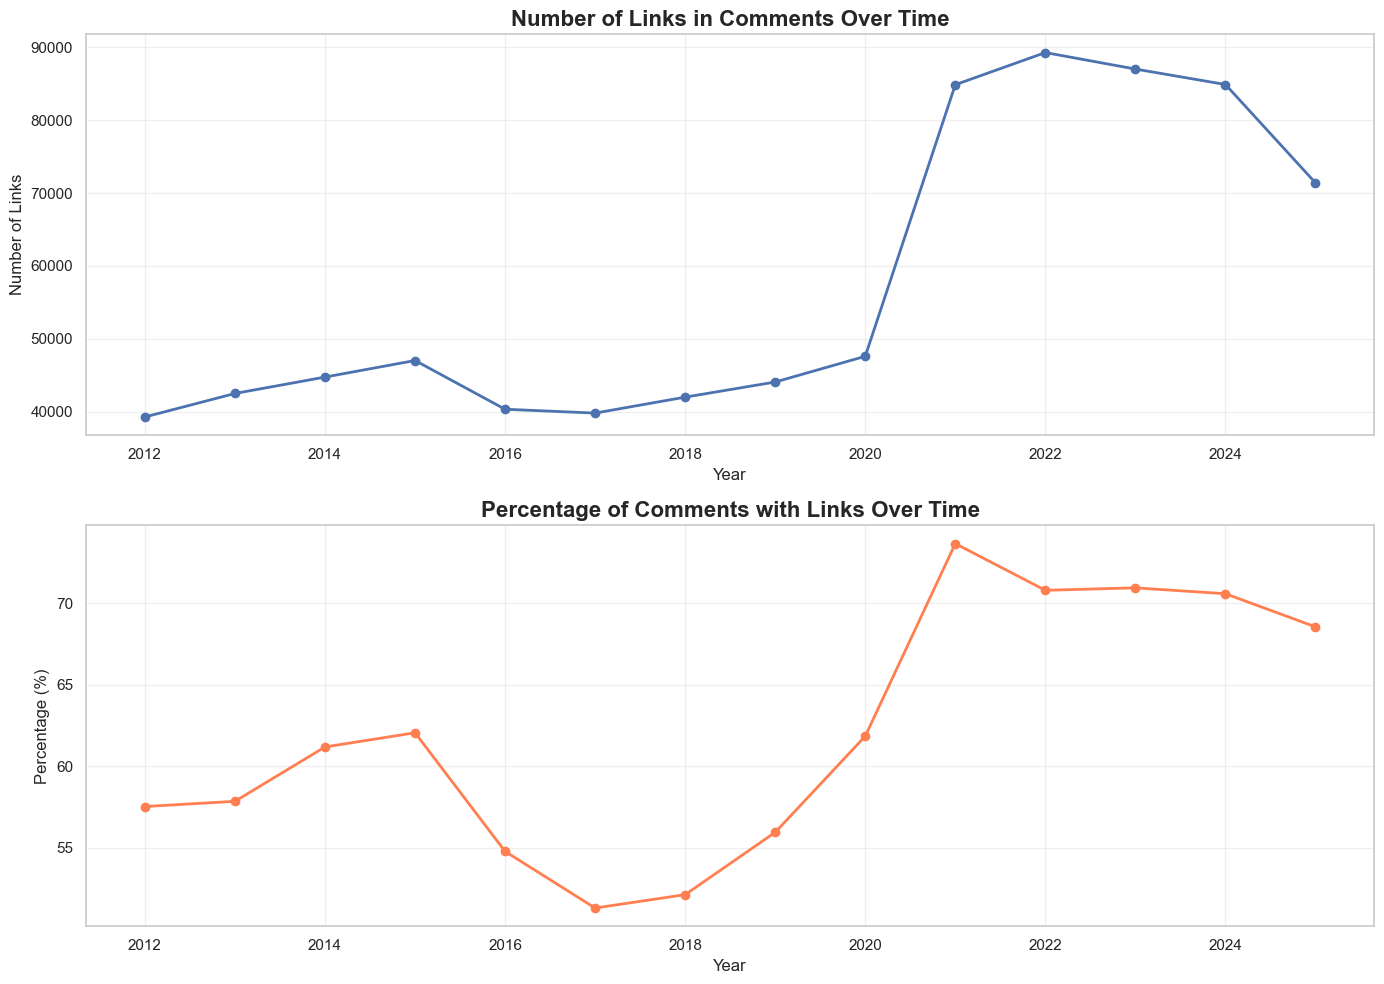

In [8]:
# Parse airdate and extract year
# Use utc=True to handle mixed timezones properly
urls_df['airdate_parsed'] = pd.to_datetime(urls_df['airdate'], errors='coerce', utc=True)
# Ensure it's a proper datetime dtype (not object)
if urls_df['airdate_parsed'].dtype == 'object':
    urls_df['airdate_parsed'] = pd.to_datetime(urls_df['airdate_parsed'], errors='coerce')
# Convert timezone-aware to naive if needed for .dt accessor
# Check if it's a DatetimeTZDtype (timezone-aware)
if isinstance(urls_df['airdate_parsed'].dtype, pd.core.dtypes.dtypes.DatetimeTZDtype):
    urls_df['airdate_parsed'] = urls_df['airdate_parsed'].dt.tz_convert('UTC').dt.tz_localize(None)

urls_df['year'] = urls_df['airdate_parsed'].dt.year
urls_df['month'] = urls_df['airdate_parsed'].dt.month

# Links per year
links_by_year = urls_df.groupby('year').size()

# Parse comments airdate for grouping
comments_df['airdate_parsed'] = pd.to_datetime(comments_df['airdate'], errors='coerce', utc=True)
if comments_df['airdate_parsed'].dtype == 'object':
    comments_df['airdate_parsed'] = pd.to_datetime(comments_df['airdate_parsed'], errors='coerce')
if isinstance(comments_df['airdate_parsed'].dtype, pd.core.dtypes.dtypes.DatetimeTZDtype):
    comments_df['airdate_parsed'] = comments_df['airdate_parsed'].dt.tz_convert('UTC').dt.tz_localize(None)
comments_df['year'] = comments_df['airdate_parsed'].dt.year
comments_by_year = comments_df.groupby('year').size()

# Parse comments_with_links airdate
comments_with_links['airdate_parsed'] = pd.to_datetime(comments_with_links['airdate'], errors='coerce', utc=True)
if comments_with_links['airdate_parsed'].dtype == 'object':
    comments_with_links['airdate_parsed'] = pd.to_datetime(comments_with_links['airdate_parsed'], errors='coerce')
if isinstance(comments_with_links['airdate_parsed'].dtype, pd.core.dtypes.dtypes.DatetimeTZDtype):
    comments_with_links['airdate_parsed'] = comments_with_links['airdate_parsed'].dt.tz_convert('UTC').dt.tz_localize(None)
comments_with_links['year'] = comments_with_links['airdate_parsed'].dt.year

# Calculate percentage of comments with links per year
yearly_stats = pd.DataFrame({
    'total_comments': comments_by_year,
    'links': links_by_year,
    'comments_with_links': comments_with_links.groupby('year').size()
})
yearly_stats['pct_with_links'] = (yearly_stats['comments_with_links'] / yearly_stats['total_comments'] * 100).round(2)

print("Links per Year:")
print(yearly_stats)

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Links over time
ax1.plot(links_by_year.index, links_by_year.values, marker='o', linewidth=2, markersize=6)
ax1.set_title('Number of Links in Comments Over Time', fontsize=16, fontweight='bold')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Number of Links', fontsize=12)
ax1.grid(True, alpha=0.3)

# Percentage with links
ax2.plot(yearly_stats.index, yearly_stats['pct_with_links'], marker='o', linewidth=2, markersize=6, color='coral')
ax2.set_title('Percentage of Comments with Links Over Time', fontsize=16, fontweight='bold')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Category Trends Over Time


Category trends by year:
category  Music Platform  News/Media  Other  Social Media  Video  Website
year                                                                     
2012.0              1983       16153   2186          1481   2235    15278
2013.0              2789       16549   2497          2063   2330    16306
2014.0              2902       18794   1397          2403   2224    17060
2015.0              3607       17518   2366          3081   3425    17053
2016.0              4328       10978   2149          2684   5555    14679
2017.0              5571        8185   3278          2376   7690    12746
2018.0              6446        5529   5302          2344   9841    12570
2019.0              8483        4418   6770          1681  10899    11853
2020.0             12266        5000   5571          2533  10081    12178
2021.0             19617        7609  14047          2685  19520    21358
2022.0             19432        9487  15456          2601  19137    23130
2023.0       

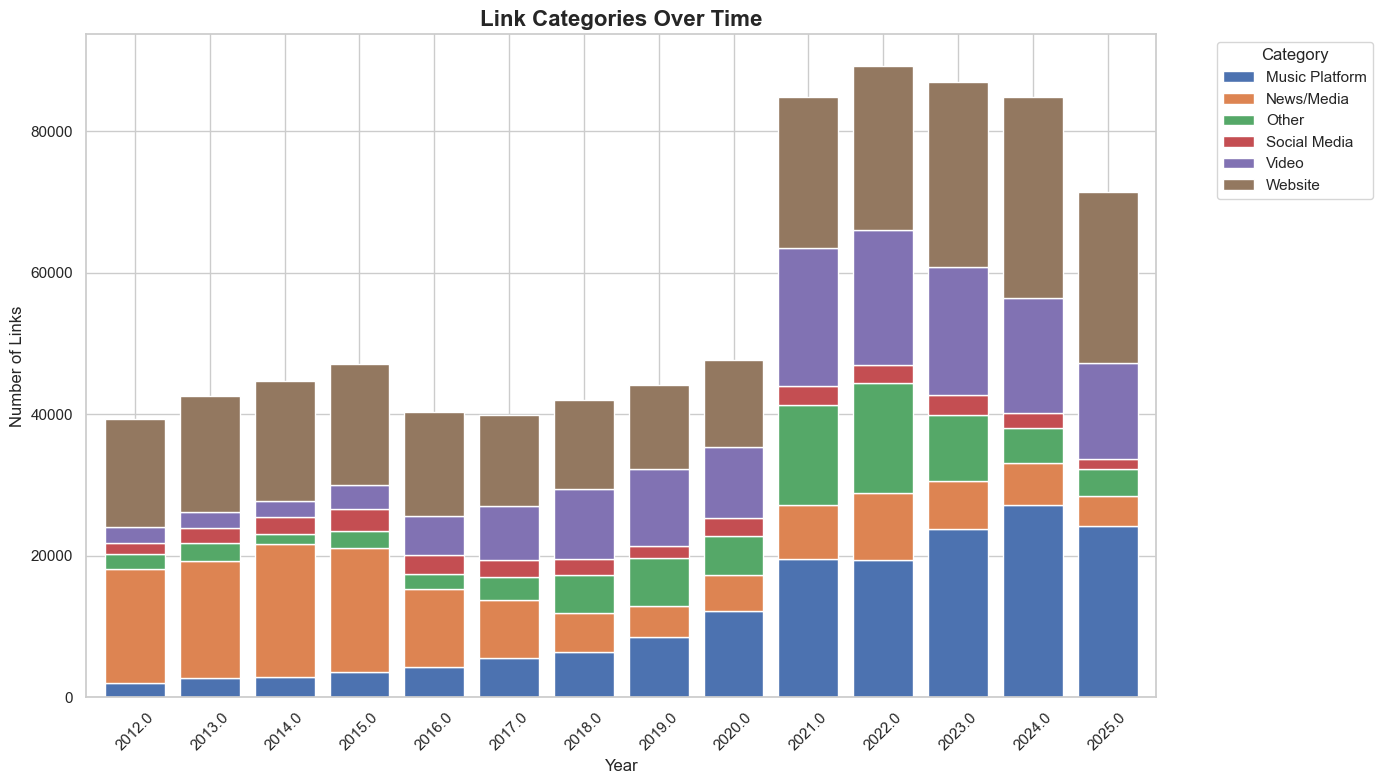

In [9]:
# Category trends by year
category_trends = urls_df.groupby(['year', 'category']).size().unstack(fill_value=0)

print("Category trends by year:")
print(category_trends)

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
category_trends.plot(kind='bar', stacked=True, ax=ax, width=0.8)
ax.set_title('Link Categories Over Time', fontsize=16, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Links', fontsize=12)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Sample Comments with Links


In [10]:
# Show sample comments with multiple links
multi_link_comments = comments_with_links[comments_with_links['url_count'] > 1].sort_values('url_count', ascending=False)

print(f"Comments with multiple links: {len(multi_link_comments):,}")
print(f"Max links in a single comment: {comments_with_links['url_count'].max()}")

print("\nSample comments with multiple links:")
for idx, row in multi_link_comments.head(5).iterrows():
    print(f"\n--- Play ID: {row['id']} | {row['airdate']} ---")
    print(f"Artist: {row['artist']} - {row['song']}")
    print(f"Links ({row['url_count']}):")
    for url in row['urls']:
        print(f"  - {url}")
    print(f"Comment: {row['comment'][:200]}...")


Comments with multiple links: 104,943
Max links in a single comment: 9

Sample comments with multiple links:

--- Play ID: 2933946 | 2021-09-02T06:15:21-07:00 ---
Artist: Tank and the Bangas feat. feat. David Shaw, PJ Morton, Alexis Marceaux, Anjelika Jelly Joseph, Maggie Koerner, Sasha Masakowski, Berkley the Artist, Rahim Glaspy & Tracci Lee - What the World Needs Now
Links (9):
  - https://youtu.be/xNwVBFguaeE
  - http://www.tankandthebangas.com/
  - https://www.pjmortonmusic.com/
  - https://www.davidshaw.com/
  - https://www.maggiekoerner.com/
  - https://www.sashamasakowski.com/
  - http://berkleytheartist.com/
  - https://thegreatglaspy.bandcamp.com/releases
  - https://www.facebook.com/Jelly-Joseph-382337035273191/
Comment: Just before the pandemic shutdown Tank and the Bangas and a slew of New Orleans musicians came together to create this beautiful song.
https://youtu.be/xNwVBFguaeE

Support New Orleans musicians!
http...

--- Play ID: 3488007 | 2025-04-12T16:37:29-07:00 ---


## Summary Statistics


In [12]:
print("=" * 60)
print("KEXP COMMENT LINKS EXPLORATION - SUMMARY")
print("=" * 60)

print(f"\nTotal comments in database: {len(comments_df):,}")
print(f"Comments with links: {len(comments_with_links):,} ({len(comments_with_links)/len(comments_df)*100:.2f}%)")
print(f"Total URLs found: {len(urls_df):,}")
print(f"Unique URLs: {urls_df['url'].nunique():,}")
print(f"Unique domains: {urls_df['domain'].nunique():,}")

# Compute category counts if not already defined
if 'category_counts' not in globals():
    category_counts = urls_df['category'].value_counts()

print(f"\nLink Categories:")
for cat, count in category_counts.items():
    pct = count / len(urls_df) * 100
    print(f"  {cat}: {count:,} ({pct:.2f}%)")

# Compute top domains if not already defined
if 'top_domains' not in globals():
    top_domains = urls_df['domain'].value_counts().head(20)

print(f"\nTop 5 Domains:")
for domain, count in top_domains.head(5).items():
    pct = count / len(urls_df) * 100
    print(f"  {domain}: {count:,} ({pct:.2f}%)")

print(f"\nAverage URLs per comment (with links): {comments_with_links['url_count'].mean():.2f}")
print(f"Max URLs in single comment: {comments_with_links['url_count'].max()}")

print("\n" + "=" * 60)


KEXP COMMENT LINKS EXPLORATION - SUMMARY

Total comments in database: 1,075,082
Comments with links: 674,490 (62.74%)
Total URLs found: 810,083
Unique URLs: 290,897
Unique domains: 49,719

Link Categories:
  Website: 254,342 (31.40%)
  Music Platform: 163,138 (20.14%)
  Video: 142,067 (17.54%)
  News/Media: 137,719 (17.00%)
  Other: 80,505 (9.94%)
  Social Media: 32,312 (3.99%)

Top 5 Domains:
  youtube.com: 103,211 (12.74%)
  kexp.org: 71,862 (8.87%)
  bit.ly: 55,362 (6.83%)
  blog.kexp.org: 50,310 (6.21%)
  youtu.be: 37,921 (4.68%)

Average URLs per comment (with links): 1.20
Max URLs in single comment: 9



## Export Results (Optional)

Uncomment the cell below to export the URL dataset to CSV for further analysis.


In [ ]:
# Uncomment to export
# urls_df.to_csv('../comment_links_dataset.csv', index=False)
# print("Exported to comment_links_dataset.csv")
